# Venn Diagrams and Inclusion–Exclusion

**This notebook is self-contained — it re-introduces the sets it needs from scratch.**

A **Venn diagram** is a picture of sets: each set is drawn as a circle, and circles overlap where their sets share members. It turns abstract set operations into something you can see — the overlap of two circles is their **intersection**, the total area covered is their **union**, and the area outside every circle is what belongs to none of them. This notebook builds Venn diagrams for two and three groups of patients and uses them to derive the counting rule behind them: **inclusion–exclusion**.

## Learning objectives

- Split a universe into the regions of a Venn diagram and count each one.
- Explain and verify the inclusion–exclusion rule $|A \cup B| = |A| + |B| - |A \cap B|$.
- Read a three-set Venn diagram.

## Background

Restated so this notebook stands on its own: a **set** is a collection of items; the **union** $A \cup B$ is everything in either set, the **intersection** $A \cap B$ is what is in both, and $|A|$ is the number of elements in $A$.

If you simply add $|A| + |B|$ to count the union, you count everyone in the overlap **twice** — once as a member of $A$ and once as a member of $B$. Subtracting the overlap $|A \cap B|$ exactly once corrects this. That is the **inclusion–exclusion** rule:

$$|A \cup B| = |A| + |B| - |A \cap B|.$$

## This notebook covers

1. Rebuild the patient group and its sets.
2. The four regions of a two-set diagram.
3. Inclusion–exclusion, explained and checked.
4. A three-set Venn diagram, and inclusion–exclusion for three sets.

**Prerequisites:** `U1-2_Sets-1_Operations`

**Dataset:** the same tiny synthetic cohort, rebuilt inline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

## 1. The patient group and its sets

So the notebook stands on its own, we rebuild the same eight-patient table and, from it, three sets: $A$ = patients with diabetes, $B$ = with hypertension, $C$ = with obesity. Each set is collected with a simple loop over the rows (add a patient's name to a set when their column says `True`).

In [2]:
# Build a tiny cohort by hand: one row per patient.
cohort = pd.DataFrame({
    "Patient":      ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8"],
    "Diabetes":     [True,  True,  False, True,  False, True,  False, False],
    "Hypertension": [True,  False, True,  True,  False, False, True,  False],
    "Obesity":      [False, True,  True,  False, False, True,  True,  False],
})
cohort

,Patient,Diabetes,Hypertension,Obesity
0,P1,True,True,False
1,P2,True,False,True
2,P3,False,True,True
3,P4,True,True,False
4,P5,False,False,False
5,P6,True,False,True
6,P7,False,True,True
7,P8,False,False,False


In [3]:
U = set(cohort["Patient"])

# Build the three sets with simple loops.
A = set()   # diabetes
B = set()   # hypertension
C = set()   # obesity
for i in range(len(cohort)):
    if cohort.loc[i, "Diabetes"] == True:
        A.add(cohort.loc[i, "Patient"])
    if cohort.loc[i, "Hypertension"] == True:
        B.add(cohort.loc[i, "Patient"])
    if cohort.loc[i, "Obesity"] == True:
        C.add(cohort.loc[i, "Patient"])

print("A =", A)
print("B =", B)
print("C =", C)

A = {'P2', 'P1', 'P6', 'P4'}
B = {'P3', 'P1', 'P7', 'P4'}
C = {'P2', 'P7', 'P3', 'P6'}


## 2. The four regions of a two-set diagram

Using just $A$ (diabetes) and $B$ (hypertension), every patient falls into exactly **one** of four regions:

- **only $A$** — has diabetes but not hypertension,
- **only $B$** — has hypertension but not diabetes,
- **both** — has both conditions,
- **neither** — has neither.

We compute each count with set operations ($A - B$ is "in $A$ but not $B$", $A \cap B$ is "in both", $U - (A \cup B)$ is "in neither"), then draw the two circles and label each region.

*(The drawing code is only there to make the picture — you can ignore its mechanics; the region counts are the point.)*

diabetes only: 2  hypertension only: 2  both: 2  neither: 2


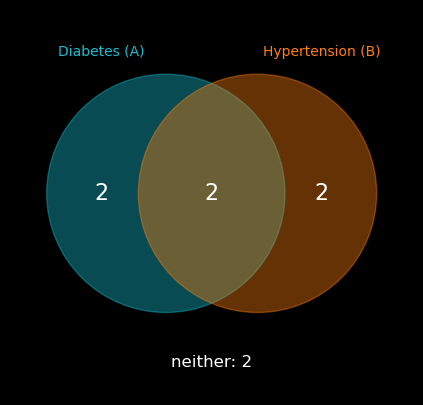

In [4]:
# --- the math: count patients in each region ---
only_A = len(A - B)         # diabetes only
only_B = len(B - A)         # hypertension only
both = len(A & B)           # both
neither = len(U - (A | B))  # neither

print("diabetes only:", only_A, " hypertension only:", only_B,
      " both:", both, " neither:", neither)

# --- graphics: two overlapping circles (mechanics, not the point) ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.add_patch(plt.Circle((-0.5, 0), 1.3, color="tab:cyan", alpha=0.4))
ax.add_patch(plt.Circle((0.5, 0), 1.3, color="tab:orange", alpha=0.4))
ax.text(-1.2, 0, str(only_A), fontsize=16, ha="center", va="center")
ax.text(1.2, 0, str(only_B), fontsize=16, ha="center", va="center")
ax.text(0.0, 0, str(both), fontsize=16, ha="center", va="center")
ax.text(0.0, -1.9, "neither: " + str(neither), fontsize=12, ha="center")
ax.text(-1.2, 1.5, "Diabetes (A)", ha="center", color="tab:cyan")
ax.text(1.2, 1.5, "Hypertension (B)", ha="center", color="tab:orange")
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.0)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

## 3. Inclusion–exclusion, explained

Suppose diabetes has $|A|$ patients and hypertension has $|B|$. If we add $|A| + |B|$ to get the size of the combined group, everyone who has **both** conditions is counted twice — once inside $A$'s count and once inside $B$'s. To fix that double-count we subtract the overlap $|A \cap B|$ exactly once:

$$|A \cup B| = |A| + |B| - |A \cap B|.$$

Let's check this prediction against the actual number of patients in the union.

In [5]:
predicted = len(A) + len(B) - len(A & B)
actual = len(A | B)

print("|A| =", len(A), "  |B| =", len(B), "  |A and B| =", len(A & B))
print("Inclusion-exclusion predicts |A or B| =", predicted)
print("Actual |A or B|                       =", actual)
print("Match?", predicted == actual)

|A| = 4   |B| = 4   |A and B| = 2
Inclusion-exclusion predicts |A or B| = 6
Actual |A or B|                       = 6
Match? True


The prediction matches because subtracting $|A \cap B|$ removes the double-count of the overlap region — that overlap is exactly the lens-shaped area in the middle of the Venn diagram.

## 4. A three-set Venn diagram

Adding obesity ($C$) as a third circle creates more regions: three "only" regions, three "exactly two" overlaps, one "all three" region in the center, and the "none" region outside — eight in total. We count each with set operations and draw all three circles.

A only: 0  B only: 0  C only: 0
A&B: 2  A&C: 2  B&C: 2  all three: 0  none: 2


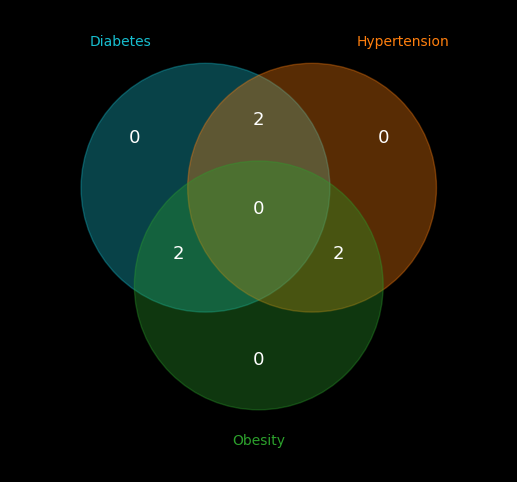

In [6]:
# Count each of the seven regions with plain set operations.
only_A = len(A - B - C)
only_B = len(B - A - C)
only_C = len(C - A - B)
A_and_B = len((A & B) - C)
A_and_C = len((A & C) - B)
B_and_C = len((B & C) - A)
all_three = len(A & B & C)
none = len(U - (A | B | C))

print("A only:", only_A, " B only:", only_B, " C only:", only_C)
print("A&B:", A_and_B, " A&C:", A_and_C, " B&C:", B_and_C,
      " all three:", all_three, " none:", none)

# --- graphics: three overlapping circles (mechanics only) ---
fig, ax = plt.subplots(figsize=(7, 6))
ax.add_patch(plt.Circle((-0.6, 0.4), 1.4, color="tab:cyan", alpha=0.35))
ax.add_patch(plt.Circle((0.6, 0.4), 1.4, color="tab:orange", alpha=0.35))
ax.add_patch(plt.Circle((0.0, -0.7), 1.4, color="tab:green", alpha=0.35))
ax.text(-1.4, 0.9, str(only_A), fontsize=13, ha="center")
ax.text(1.4, 0.9, str(only_B), fontsize=13, ha="center")
ax.text(0.0, -1.6, str(only_C), fontsize=13, ha="center")
ax.text(0.0, 1.1, str(A_and_B), fontsize=13, ha="center")
ax.text(-0.9, -0.4, str(A_and_C), fontsize=13, ha="center")
ax.text(0.9, -0.4, str(B_and_C), fontsize=13, ha="center")
ax.text(0.0, 0.1, str(all_three), fontsize=13, ha="center")
ax.text(-1.9, 2.0, "Diabetes", color="tab:cyan")
ax.text(1.1, 2.0, "Hypertension", color="tab:orange")
ax.text(0.0, -2.5, "Obesity", color="tab:green", ha="center")
ax.set_xlim(-2.8, 2.8)
ax.set_ylim(-2.8, 2.4)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

### 4.1 Inclusion–exclusion with three sets

The two-set rule extends, and the pattern is worth seeing. Add the three sets; that double-counts
every pairwise overlap, so subtract them; but the triple overlap has now been added three times and
subtracted three times, leaving it out altogether — so add it back once:

$$|A \cup B \cup C| = |A| + |B| + |C| - |A \cap B| - |A \cap C| - |B \cap C| + |A \cap B \cap C|$$

Add, subtract, add — the signs alternate, and they keep alternating however many sets you have. Let
us check the prediction against a direct count.


In [7]:
predicted = (len(A) + len(B) + len(C)
             - len(A & B) - len(A & C) - len(B & C)
             + len(A & B & C))
actual = len(A | B | C)

print(f"|A| + |B| + |C|              = {len(A) + len(B) + len(C)}")
print(f"minus the three pair overlaps = -{len(A & B) + len(A & C) + len(B & C)}")
print(f"plus the triple overlap       = +{len(A & B & C)}")
print(f"\ninclusion-exclusion predicts |A or B or C| = {predicted}")
print(f"actual |A or B or C|                       = {actual}")
print(f"match? {predicted == actual}")


|A| + |B| + |C|              = 12
minus the three pair overlaps = -6
plus the triple overlap       = +0

inclusion-exclusion predicts |A or B or C| = 6
actual |A or B or C|                       = 6
match? True


## 5. Summary

- A **Venn diagram** draws sets as circles; overlaps are intersections, the outside is "none".
- The universe splits into regions (only $A$, only $B$, both, neither for two sets; eight regions for three).
- **Inclusion–exclusion**, $|A \cup B| = |A| + |B| - |A \cap B|$, corrects the double-count of the overlap. With three sets you add the singles, subtract the three pairs, then add the triple overlap back — the signs alternate.

Next: the **sets of numbers** themselves — $\mathbb{N}, \mathbb{Z}, \mathbb{Q}, \mathbb{R}$ (`U1-2_Sets-3_NumberSystems`).